## Simulating SNIa with skysurvey
In this notebook, we study Supernovae Ia (SNIa) generated from our volumetric rates and see if they are detected by LSST.

You can use cartopy and these instructions in the link to visualise locations:
https://skysurvey.readthedocs.io/en/latest/howto/target_and_skyarea.html
but we do not use it in this notebook.

In [ ]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility
from lsst_functions import exist_in_multiband_check, five_sigma_detection_multiband

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import importlib
# uncomment and run the following and run them if you wantu
# importlib.reload(lsst_functions)
# importlib.reload(lightcurve)
# from lightcurve import plot_lightcurve

Load LSST as opsim (to be retrieved from the website: ). Note that the filesizes can be large 
If you want to choose only one band: band IN ('g') AND night < ...

In LSST opsim, the filters have an additional suffixes e.g. _6. For ease of coding, we replace the str using regex.

Note, unless you have sufficient processing power, loading lsst from opsim will crash VScode above 500 nights.
You would need to use a cluster to make the datasets and then reload the dataset after.

In [3]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")
# Remove the suffix or else DataSet.from_targets_and_survey() will have mismatched filter names
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

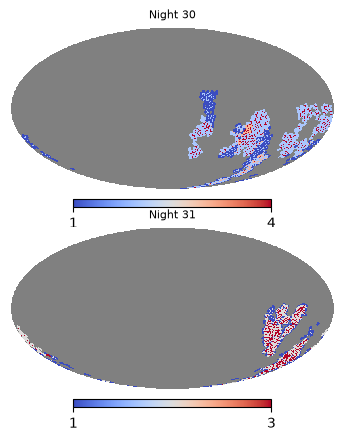

In [4]:
# visualise nightly coverage (important if you specifically want to use a specific night)
from lsst_functions import visualize_nights
visualize_nights(opsim_path = opsim_path, start_night = 30, stop_night = 32, vmax_quantile=0.95, cmap = "coolwarm")

In [5]:
#  llod the date range across all the nights
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

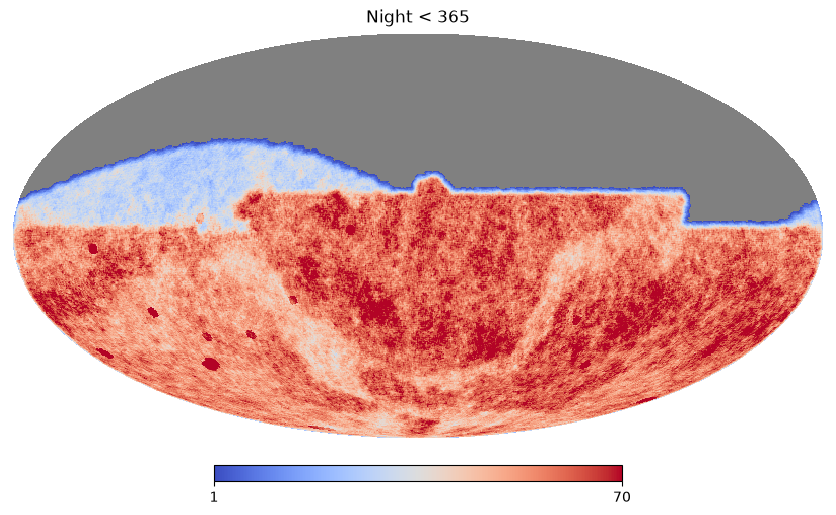

In [6]:
# uncomment the following if you want to see the field coverage for your given opsim
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night < 365')
# average over southern sky. could also take average below 30 deg dec --> we dk what new info we will get
# but we will in principle be simulating more sources

In [7]:
lsst.data.head() # gives all info about the observation over all the nights (e.g skynoise and in what band). Returns pandas.df

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
0,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474007
1,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474008
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
3,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474010
4,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474011


To look at observations across all filters in a given field id, use:
<code> select_fieldid = (lsst.data['fieldid'] == 336769) </code>
<code> lsst.data[select_fieldid] </code>

When generating a population, we always use these three back-to-back:
Theoretical lightcurves are simulated from phase $\in$ [-20, 50], which are days w.r.t peak time. Observations of the target in that particilar field are made at later dates too (but are less likely to have SNR > 5.)

Because we are looking at $\nu$ sources and SNIa are not expected to be a source. However, SNIa are useful for cosmo studies and the background of transients that we detect.

There are 2 completeness we can compute and compare: Simulated vs Detected

Until <code>z = 10</code>. We will detect until here. Total detected over the total . can make a fancy plot (with shaded until <code>z = 1.0</code>). We want a value of how many in full universe (4 pi u sr)

In [8]:
snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
# snia_dict = generate_snia_dict(redshift = 0.2, ra = 14.9, dec = -22.9, x1 = 0, t0 = None, magabs = -19.323, c = 0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = lsst_bands, in_mag = False, N_tot = 1000, tstart = tmin -100, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x774425276fb0>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x77442543d0c0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774429708a90>, 'kwargs': {'dec_range': [-90, 90]}}}


<b> Essential functions: </b>

<code>skysurvey.Target.core.data.loc[index]</code>
- To see a pd.Series of the data specific target transient of a particular index, use .loc[index]. (Note: using .iloc[5] will give the 5th target regardless of index number)

<code>plot_lightcurve()</code> (from <code>lightcurve.py</code>)
- uses the lightcurve times + flux values to plot theoretical lightcurves for a given object. Useful for comparing with theoretical flux/mag limits.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.

<b>Functions:</b>

- <code>skysurvey.dataset.get_target_lightcurve(self, index, detection=None, phase_range=None)</code> gives a dataframe of diff index_obs with columns: field params.
- <code>skysurvey.dataset.get_data</code> gives a dataframe of obs of a particular index. You can filter depending on <code>detection = bool or None.</code>
- <code>lightcurve.show_target_lightcurve()</code>: Shows theoretical lightcurve of one index + simulated observations from skysurvey.

In [9]:
snia_models.data.tail()

,z,x1,c,t0,ra,dec,magabs,magobs,template
995,0.374982,-1.260,0.077,61507.859375,123.668373,-9.170797,-18.851011,22.735668,salt2
996,0.379401,-0.775,0.128,61133.351562,250.939224,14.447675,-18.784611,22.831894,salt2
997,0.960300,-1.230,-0.050,61312.242188,217.165070,-36.103134,-19.339603,24.711819,salt2
998,0.221925,-2.005,0.106,61258.585938,192.085403,39.565056,-18.566921,21.712513,salt2
999,0.999306,0.445,0.061,61457.875000,17.060743,9.909497,-19.238020,24.919878,salt2


Text(0.5, 0, 'redshift z')

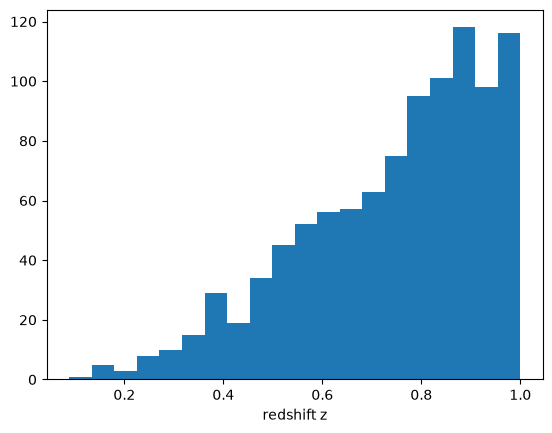

In [11]:
# visualise distribution opf redshifts with simple binning
plt.hist(snia_models.data['z'], bins = 20)
plt.xlabel('redshift z')

In [12]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 688/688 [00:13<00:00, 51.98it/s]


In [13]:
ndetections = dset.get_ndetection()

In [14]:
# find indices with n_detections more than a certain value (15 in this case)
ndetections[ndetections > 15]

index
176    17
203    26
305    22
342    23
427    28
856    20
889    17
dtype: int64

In [15]:
max_index = ndetections.idxmax()
max_value = ndetections.loc[max_index]
print(max_index, max_value)
dset

427 28


In [16]:
data_models[max_index]['params']

{'z': np.float32(0.08872711),
 'x1': np.float32(0.345),
 'c': np.float32(-0.019),
 't0': np.float32(61486.35),
 'magabs': np.float32(-19.353352),
 'ra': np.float32(197.04976),
 'dec': np.float32(-36.933147)}

In [17]:
dset.get_ndetection(per_band = True).head(50)

index  band 
2      lssti    1
       lsstr    1
       lsstz    1
12     lsstr    1
14     lssti    2
       lsstr    2
20     lssti    3
       lsstr    3
       lsstz    1
25     lsstr    2
       lsstz    1
29     lssti    2
       lsstr    1
       lsstz    3
32     lsstg    2
       lssti    2
       lsstr    2
       lsstz    3
39     lsstg    3
       lssti    2
       lsstr    3
       lsstz    4
44     lssti    2
47     lssti    1
50     lsstr    2
60     lssti    2
       lsstz    1
69     lssti    4
       lsstr    1
       lsstz    3
75     lsstr    1
84     lssti    1
       lsstr    1
99     lssti    1
       lsstr    1
102    lssti    1
104    lsstg    2
       lssti    1
       lsstr    1
       lsstz    5
110    lssti    2
124    lsstr    1
132    lssti    1
       lsstz    1
136    lssti    2
       lsstr    3
       lsstz    2
155    lssti    2
       lsstr    2
       lsstz    1
dtype: int64

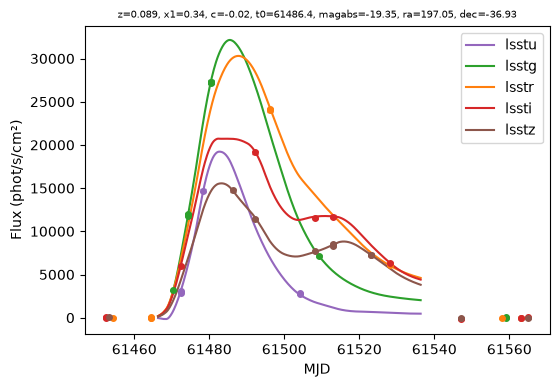

In [18]:
fig = plot_lightcurve(data_models[max_index], observed_data = dset.get_target_lightcurve(index=max_index), times = data_models[max_index]['times'], plot_limits = False)
# fig.axes[0].set_xlim(..., ...)

In [21]:
observed_data = dset.get_target_lightcurve(index=16)
observed_data.head()

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
330697,61213.433594,lssty,351.545898,1,30,384871,505.714589,351.545894
512678,61218.246094,lssty,229.012161,1,30,384871,124.116359,229.012162
517053,61218.265625,lssty,224.905304,1,30,384871,-278.706377,224.905301
1025217,61226.398438,lsstz,112.752151,1,30,384871,-27.623351,112.752152
1028585,61226.414062,lssty,293.573212,1,30,384871,-81.025861,293.573218


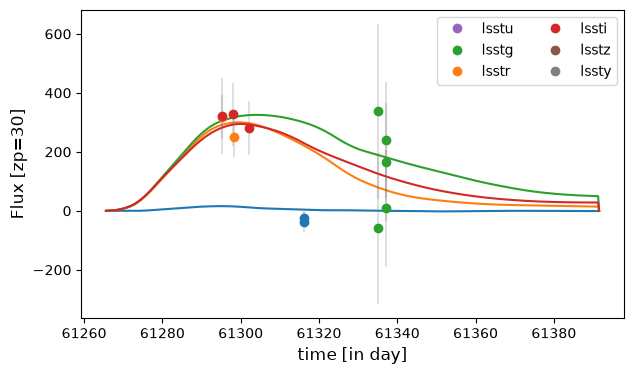

In [ ]:
from matplotlib.lines import Line2D

bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]

fig = dset.show_target_lightcurve(
    index=16,
    phase_window=[-20, 40],
    zp=30,
    format_time=False
)

ax = fig.axes[0]

handles = []

handles += [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=color,
        label=band,
    )
    for band, color in zip(bands, colors)
]

ax.legend(handles=handles, ncol=2)

plt.show()

In [33]:
from lsst_functions import get_number_detections_by_band
get_number_detections_by_band(dset, index=max_index, selection_criteria = {"total_points": 5, "n_filters": 2, "min_points_per_filter": 2})

{'lsstu': 5, 'lsstg': 8, 'lsstr': 3, 'lssti': 5, 'lsstz': 7, 'lssty': 0}

In [34]:
snia_models.data[["z", "x1", "c", "t0", "magabs", "magobs", "ra", "dec"]]

,z,x1,c,t0,magabs,magobs,ra,dec
0,0.844790,-0.100,0.020,61352.441406,-19.190388,24.518871,5.413679,-4.797646
1,0.538297,0.450,0.518,61531.734375,-17.660086,24.858751,278.458466,22.078819
2,0.661156,-0.360,0.016,61401.089844,-19.242073,23.816639,123.640694,-29.606321
3,0.991497,-0.165,0.268,61340.105469,-18.467386,25.669527,94.351189,-54.426308
4,0.815002,0.740,-0.019,61245.558594,-19.336489,24.277132,119.873703,-34.047836
...,...,...,...,...,...,...,...,...
995,0.374982,-1.260,0.077,61507.859375,-18.851011,22.735668,123.668373,-9.170797
996,0.379401,-0.775,0.128,61133.351562,-18.784611,22.831894,250.939224,14.447675
997,0.960300,-1.230,-0.050,61312.242188,-19.339603,24.711819,217.165070,-36.103134
998,0.221925,-2.005,0.106,61258.585938,-18.566921,21.712513,192.085403,39.565056


In [35]:
# if you changed the lsst_functions.py file but do not want to restart the kerne;
import importlib
importlib.reload(lsst_functions)
importlib.reload(lightcurve)

<module 'lightcurve' from '/home/denzelgoh/TransientSimulation/lightcurve.py'>

In [36]:
# import our detection functions from lsst_functions.py

# function that filters out sources based on selection criteria
from lsst_functions import five_sigma_detection_multiband

# functions for number of sources detected
from lsst_functions import detectability_sources # to return a summary of detected sources.

# functions for number of alerts predicted
from lsst_functions import get_number_detections_allbands, n_detections_sources
from lsst_functions import get_total_alerts_from_survey_by_band # this is for if you want to loop through several redshifts. It stores for every redshift.


### Filtering observations

Here, we choose a common selection criteria of 5 total dets, min. 2 dets in 2 bands

In [37]:
# set the N_tot and selection criteria. (5, 2, 2) is the default.
N_tot = 1000

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5, n_filters=2, min_points_per_filter=2)

In [ ]:
# create a dataframe with n alerts per band andsstates whether each target is visible.
detected = get_total_alerts_from_survey_by_band(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, selection_criteria = selection_criteria)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x7744693e0510>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x77442543d0c0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774429708a90>, 'kwargs': {'dec_range': [-90, 90]}}}


100%|██████████| 652/652 [00:14<00:00, 44.55it/s]


In [40]:
detected.head()

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,0,0.886656,-0.935,0.012,61352.441406,-19.152140,24.686140,67.075920,-23.358564,False,0,0,0,0,0,0,0
1,1,0.582533,-0.290,-0.006,61531.734375,-19.056055,23.669441,11.374992,6.711453,False,0,0,0,0,0,0,0
2,2,0.541717,-1.920,-0.022,61401.089844,-19.342934,23.192438,88.450584,17.949541,True,8,0,2,1,4,1,0
3,3,0.983198,0.145,0.118,61340.105469,-19.044703,25.069729,269.985626,-0.497915,False,0,0,0,0,0,0,0
4,4,0.741749,-1.565,0.401,61245.558594,-17.783594,25.579639,38.282608,73.436760,False,0,0,0,0,0,0,0


Note: The following two cells are summarised into a function called `lsst_functions.add_zbin_column()`

In [42]:
# add a column stating which redshift bin to be included in (for histogram purposes)
z_bins = np.arange(0, 1.01, 0.1) # set z bins
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
detected[(detected['detected'] == True) & (detected['n_detections'] < 6)]

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,lsstu,lsstg,lsstr,lssti,lsstz,lssty,z_bin
139,139,0.734730,0.70,0.026,61303.585938,-19.521366,23.816635,327.032166,-20.650354,True,5,0,0,0,3,2,0,"[0.7, 0.8)"
191,191,0.582743,-0.37,-0.049,61411.324219,-19.343185,23.383255,60.462990,0.676910,True,5,0,2,2,1,0,0,"[0.5, 0.6)"
491,491,0.896055,1.24,0.033,61559.304688,-19.542818,24.323612,180.434723,-37.433346,True,5,0,0,2,3,0,0,"[0.8, 0.9)"
728,728,0.661706,-1.79,-0.027,61431.441406,-19.246269,23.814638,146.219543,-14.322607,True,5,0,0,2,2,1,0,"[0.6, 0.7)"
804,804,0.511879,-0.30,0.020,61435.546875,-19.088770,23.298916,171.527161,-10.169353,True,5,0,0,3,2,0,0,"[0.5, 0.6)"


In [ ]:
detected_sources = detected[detected["detected"]]
n_sources = (detected_sources.groupby("z_bin", observed=True).size())
n_points = (detected_sources.groupby("z_bin", observed=True)["n_detections"].sum())

# print(n_sources)
print(n_points)

# see also lsst_functions.get_nsources_nalerts_per_zbin(), since it is not used
# this code is compiled in lsst_functions.add_zbin_column()

z_bin
[0.2, 0.3)     46
[0.3, 0.4)     30
[0.4, 0.5)    112
[0.5, 0.6)     58
[0.6, 0.7)     41
[0.7, 0.8)     11
[0.8, 0.9)      5
Name: n_detections, dtype: int64


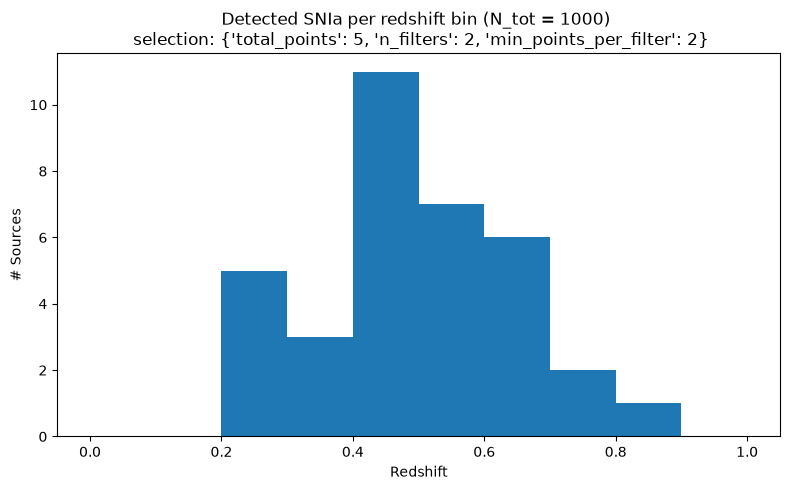

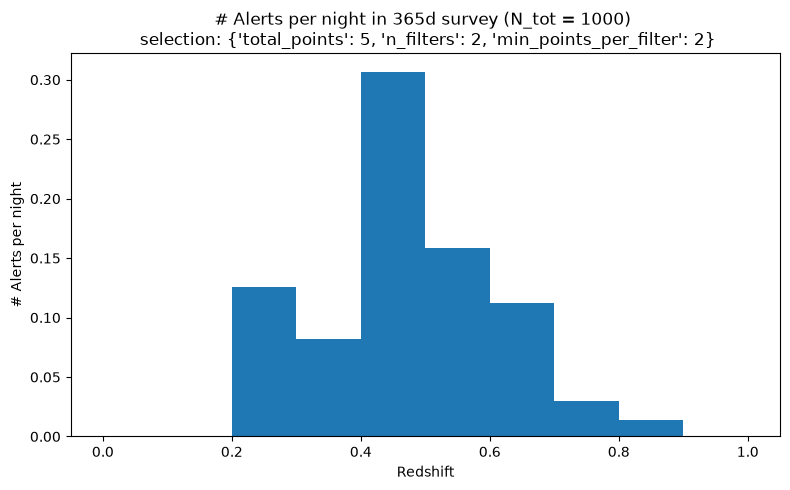

In [44]:
plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [45]:
detected = detected.drop(columns = ['z_bin'])


In [46]:
detected

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,0,0.886656,-0.935,0.012,61352.441406,-19.152140,24.686140,67.075920,-23.358564,False,0,0,0,0,0,0,0
1,1,0.582533,-0.290,-0.006,61531.734375,-19.056055,23.669441,11.374992,6.711453,False,0,0,0,0,0,0,0
2,2,0.541717,-1.920,-0.022,61401.089844,-19.342934,23.192438,88.450584,17.949541,True,8,0,2,1,4,1,0
3,3,0.983198,0.145,0.118,61340.105469,-19.044703,25.069729,269.985626,-0.497915,False,0,0,0,0,0,0,0
4,4,0.741749,-1.565,0.401,61245.558594,-17.783594,25.579639,38.282608,73.436760,False,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,0.760257,-1.305,-0.081,61507.859375,-19.315252,24.113422,76.270180,-27.327162,False,0,0,0,0,0,0,0
996,996,0.931872,-0.050,-0.034,61133.351562,-19.414085,24.557022,228.299713,22.282776,False,0,0,0,0,0,0,0
997,997,0.710312,-0.010,0.019,61312.242188,-19.202835,24.045563,175.329376,16.953352,False,0,0,0,0,0,0,0
998,998,0.872277,0.715,0.267,61258.585938,-18.471745,25.322906,254.804443,-31.674372,False,0,0,0,0,0,0,0


In [ ]:
# uncomment save to parquet
# detected.to_parquet("test_parquet.parquet",engine="pyarrow",compression="zstd",index=False)

In [ ]:
# example = pd.read_parquet('SNParquets/test_parquet.parquet')
# example

You now have a parquet with all of your 1000 sources, with columns stating their parameter values, detected (True / False), n_detections, and n_detections in each band.

You can add extra columns (e.g.fieldid) if you do further analysis.
This parquet can be used for further analysis.